In [1]:
# セル1: 必要なライブラリ
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler

print("✓ ライブラリ読み込み完了")

# セル2: 項目名の定義
df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing",
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration",
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating",
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role",
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking",
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action",
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

# セル3: 患者データ入力
patient_input = {
    # MGC 
    "MGC_ptosis": 0,
    "MGC_diplopia": 0,
    "MGC_eyelid_closure": 0,
    "MGC_speech": 0,
    "MGC_chewing": 0,
    "MGC_swallowing": 0,
    "MGC_respiration": 0,
    "MGC_neck": 0,
    "MGC_upper_limb": 0,
    "MGC_lower_limb": 0,
    # MGADL
    "MGADL_speech": 0,
    "MGADL_chewing": 0,
    "MGADL_swallowing": 0,
    "MGADL_respiration": 0,
    "MGADL_toothbrushing": 0,
    "MGADL_getting_up": 0,
    "MGADL_diplopia": 0,
    "MGADL_ptosis": 0,
    # MGQOL15r
    "MGQOL1_dissatisfaction": 0,
    "MGQOL2_seeing": 0,
    "MGQOL3_eating": 0,
    "MGQOL4_social_activity_restriction": 0,
    "MGQOL5_hobby_entertainment": 0,
    "MGQOL6_family_role": 0,
    "MGQOL7_behavior_modification": 0,
    "MGQOL8_work_impact": 0,
    "MGQOL9_speaking": 0,
    "MGQOL10_driving": 0,
    "MGQOL11_feeling_down": 0,
    "MGQOL12_walking": 0,
    "MGQOL13_quick_action": 0,
    "MGQOL14_mental_crushing": 0,
    "MGQOL15_dressing": 0
}

patient_data = pd.DataFrame([patient_input])
print("✓ データ準備完了")
display(patient_data)

✓ ライブラリ読み込み完了
✓ データ準備完了


,MGC_ptosis,MGC_diplopia,MGC_eyelid_closure,MGC_speech,MGC_chewing,MGC_swallowing,MGC_respiration,MGC_neck,MGC_upper_limb,MGC_lower_limb,...,MGQOL6_family_role,MGQOL7_behavior_modification,MGQOL8_work_impact,MGQOL9_speaking,MGQOL10_driving,MGQOL11_feeling_down,MGQOL12_walking,MGQOL13_quick_action,MGQOL14_mental_crushing,MGQOL15_dressing
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# セル4: 元のコード - データ読み込み
original_df_path = "./data/df_4th.csv"
df_ori = pd.read_csv(original_df_path, index_col=0)

with open('./out/H_matrix.pkl', 'rb') as file:
    H = pickle.load(file)

max_iter = 100

df = df_ori[df_names]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 患者データをスケーリング（df_val_scaledの代わり）
patient_data_scaled = pd.DataFrame(scaler.transform(patient_data[df_names]), columns=df_names)

print("✓ 訓練データとH行列読み込み完了")

# セル5: モデル読み込み
def load_all_fold_models(base_path='./out/'):
    with open(f"{base_path}all_fold_models_info.pkl", 'rb') as file:
        model_info = pickle.load(file)
    all_models = {}
    for model_name in model_info['model_names']:
        all_models[model_name] = []
        for fold_idx in range(model_info['num_folds']):
            filename = f"{base_path}{model_name.lower().replace(' ', '_')}_fold_{fold_idx}.pkl"
            with open(filename, 'rb') as file:
                model = pickle.load(file)
                all_models[model_name].append(model)
    return all_models

all_fold_models_validation = load_all_fold_models()
num_folds = len(all_fold_models_validation['SVM'])

probabilities_by_fold = {
    "SVM": [[] for _ in range(num_folds)],
    "Logistic Regression": [[] for _ in range(num_folds)],
    "Random Forest": [[] for _ in range(num_folds)],
    "Naive Bayes": [[] for _ in range(num_folds)]
}

print(f"✓ モデル読み込み完了: {num_folds} folds")

# セル6: 予測実行（元のコードから該当行だけ変更）
validation_sample = patient_data_scaled.iloc[0:1]  # df_val_scaled.iloc[i:i+1] から変更
concatenated_df_scaled = pd.concat([df_scaled, validation_sample], axis=0)
np.random.seed(0)

W_concatenated = np.random.rand(concatenated_df_scaled.shape[0], H.shape[0])
for _ in range(max_iter):
    numer = concatenated_df_scaled.values @ H.T
    denom = W_concatenated @ (H @ H.T)
    denom = np.where(denom == 0, 1, denom)
    W_concatenated *= numer / denom

W_validation_sample = W_concatenated[-1:, :]
X_validation = pd.DataFrame(W_validation_sample, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])

print("\nモジュールスコア:")
display(X_validation)

for fold_idx in range(num_folds):
    for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
        model = all_fold_models_validation[model_name][fold_idx]
        prob = model.predict_proba(X_validation)[:, 1][0]
        probabilities_by_fold[model_name][fold_idx].append(prob)

# セル7: 結果表示
print("\n" + "=" * 70)
print("【予測結果】")
print("=" * 70)

for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
    probs = [probabilities_by_fold[model_name][fold_idx][0] for fold_idx in range(num_folds)]
    print(f"{model_name}: {np.mean(probs):.3f}")

# アンサンブル
all_probs = []
for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
    for fold_idx in range(num_folds):
        all_probs.append(probabilities_by_fold[model_name][fold_idx][0])

ensemble_prob = np.mean(all_probs)
print(f"\nアンサンブル: {ensemble_prob:.3f} ({ensemble_prob*100:.1f}%)")
print("=" * 70)

✓ 訓練データとH行列読み込み完了
✓ モデル読み込み完了: 5 folds

モジュールスコア:


,module QOL,module Diplopia,module Ptosis,module Systemic
0,0.0,0.0,0.0,0.0



【予測結果】
SVM: 0.972
Logistic Regression: 0.641
Random Forest: 0.993
Naive Bayes: 0.993

アンサンブル: 0.900 (90.0%)


復元されたモジュール順序:
['module QOL', 'module Diplopia', 'module Ptosis', 'module Systemic']

✓ 図を保存: ./fig/prediction_radar.pdf


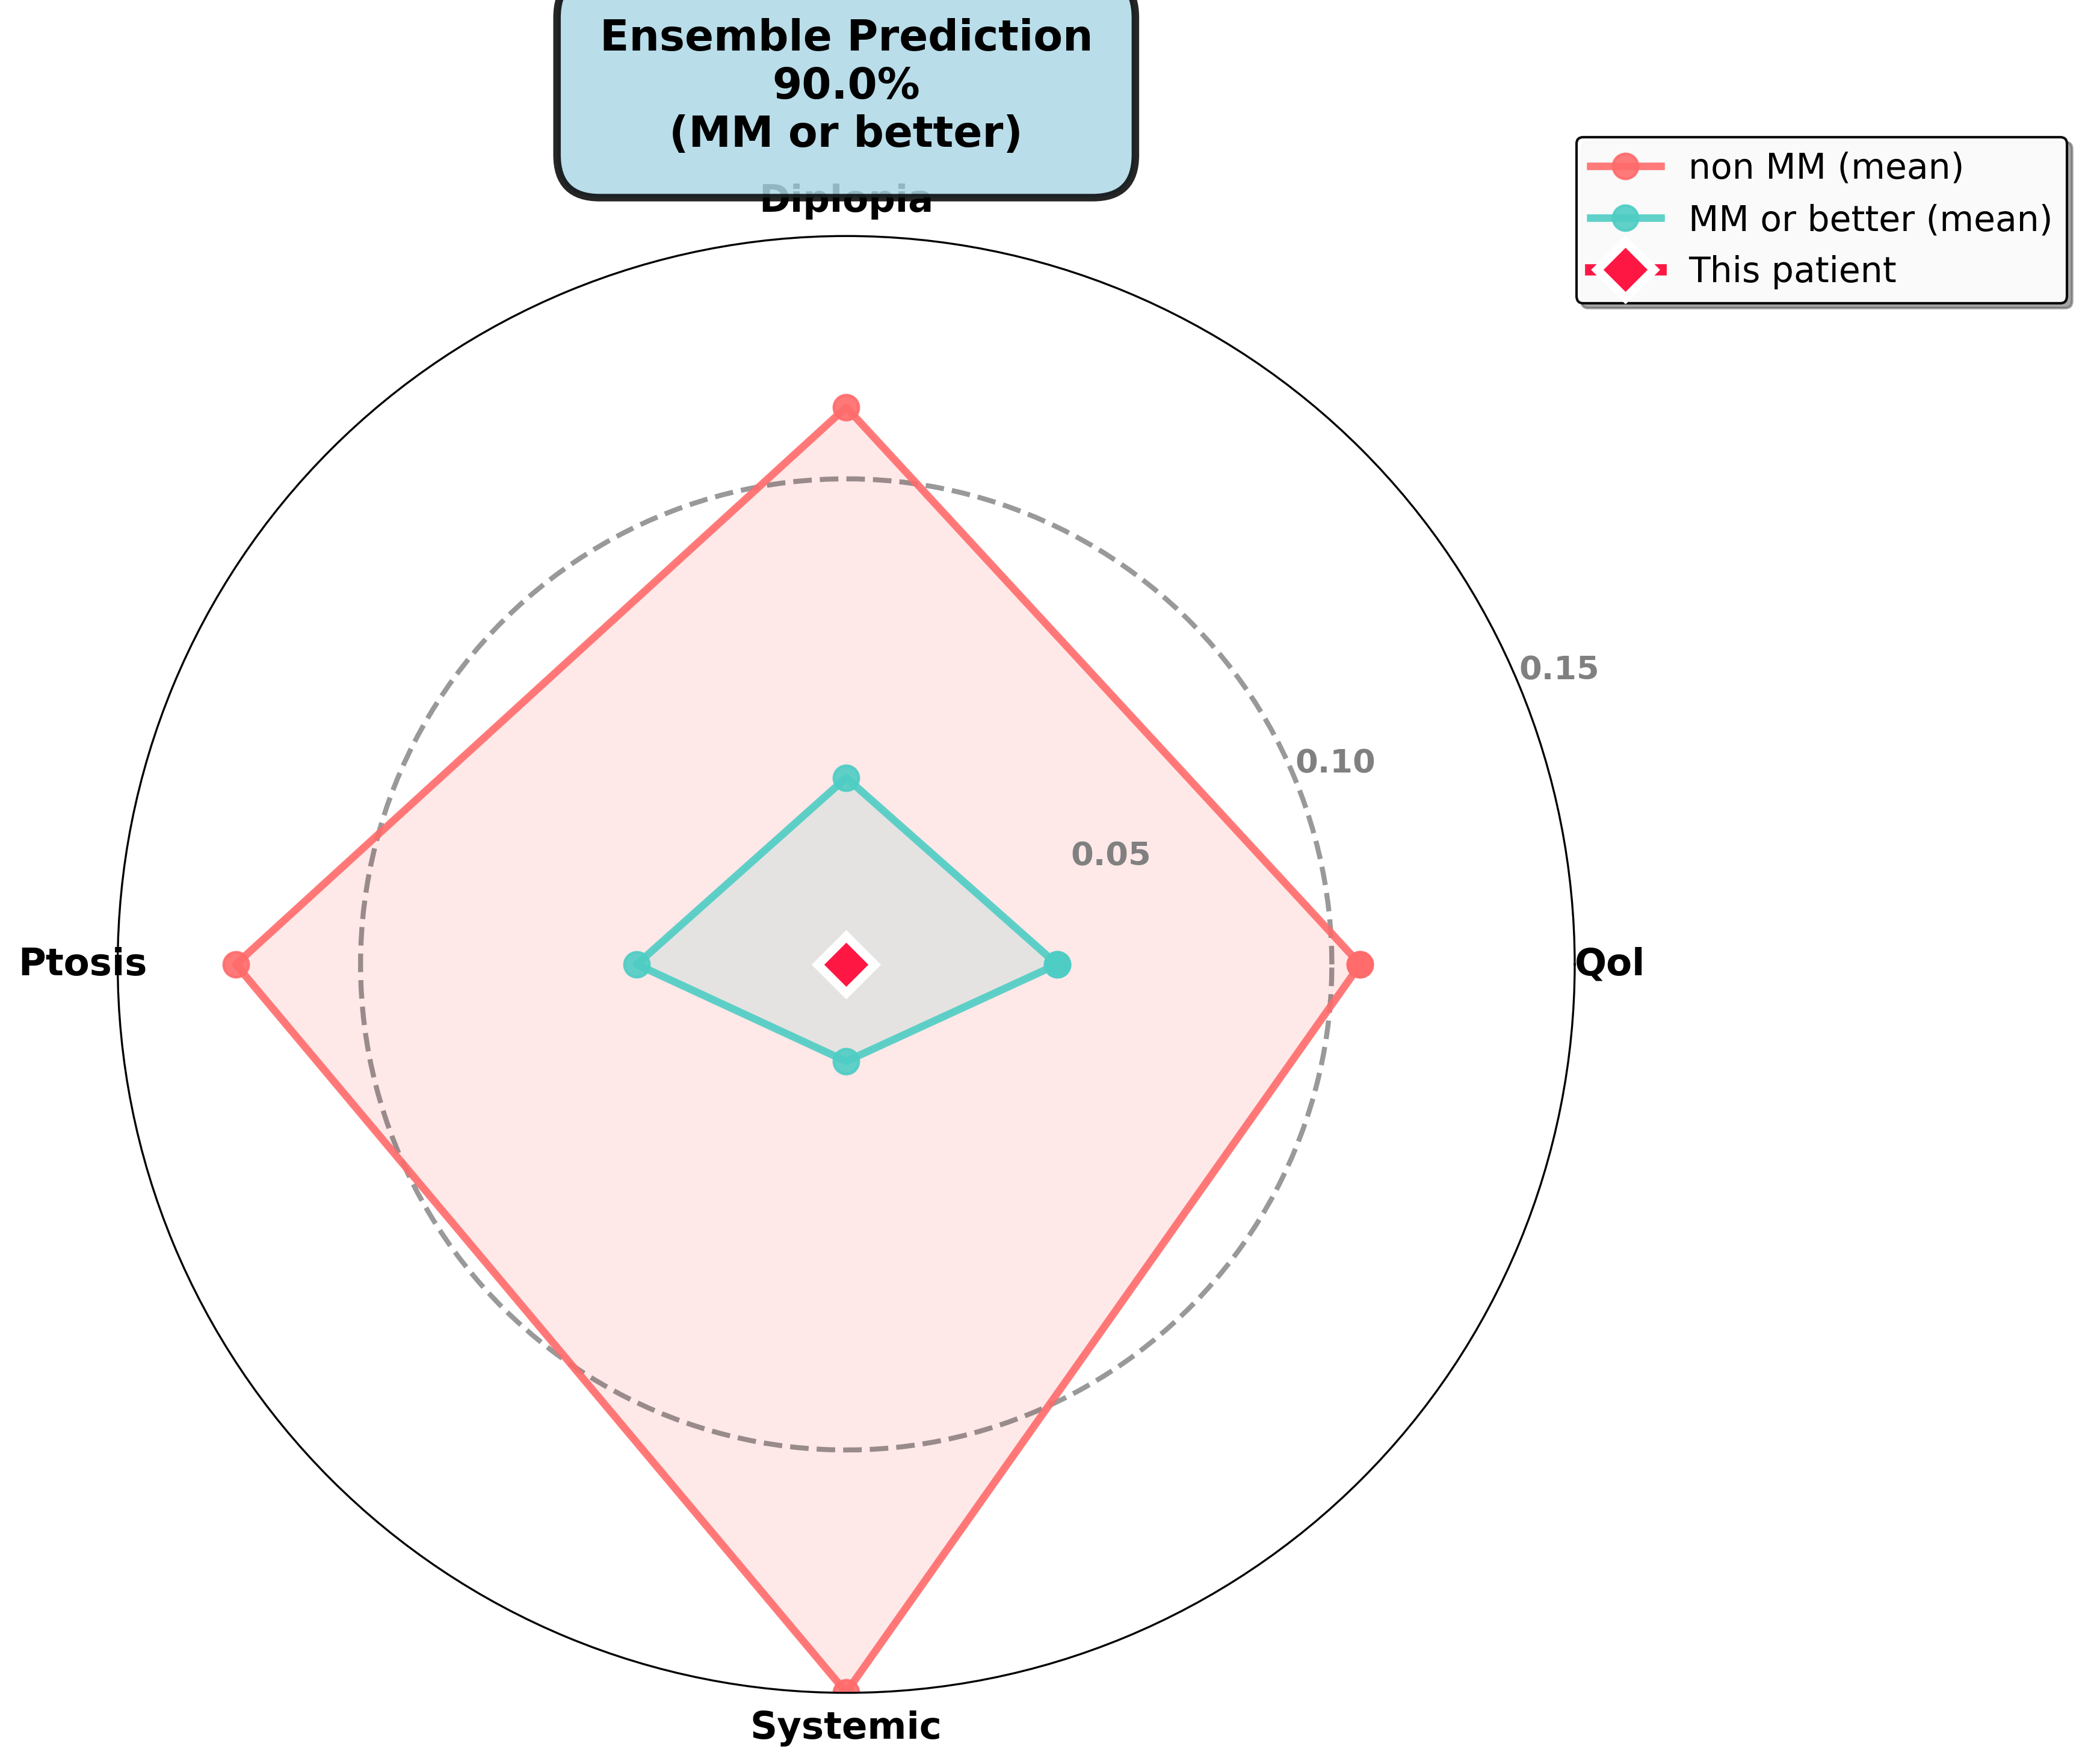


【Module Scores Comparison】
  Module  non MM (mean)  MM or better (mean)  This patient  Diff vs MM
     Qol         0.1058               0.0434           0.0     -0.0434
Diplopia         0.1147               0.0384           0.0     -0.0384
  Ptosis         0.1257               0.0431           0.0     -0.0431
Systemic         0.1499               0.0200           0.0     -0.0200

【Module-wise Assessment】
✓ Qol         : 0.0000  [✓ Better than non-MM]
✓ Diplopia    : 0.0000  [✓ Better than non-MM]
✓ Ptosis      : 0.0000  [✓ Better than non-MM]
✓ Systemic    : 0.0000  [✓ Better than non-MM]

Ensemble Prediction:      0.900 (90.0%)
Classification:           MM or better


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# --------------------
# 1) 既存ファイルから順序を復元
# --------------------
with open('./out/W_MM.pkl', 'rb') as f:
    W_MM = pickle.load(f)

module_names_ordered = [col for col in W_MM.columns if col not in ['ID', 'MMorbetter']]

print("復元されたモジュール順序:")
print(module_names_ordered)

# 保存
with open('./out/module_names_reordered.pkl', 'wb') as f:
    pickle.dump(module_names_ordered, f)

# --------------------
# 2) MM群/non MM群の平均値
# --------------------
MM_group = W_MM[W_MM["MMorbetter"] == 1][module_names_ordered].mean()
non_MM_group = W_MM[W_MM["MMorbetter"] == 0][module_names_ordered].mean()

# --------------------
# 3) 患者データ
# --------------------
patient_scores_original = X_validation.iloc[0].values.copy()

# --------------------
# 4) レーダーチャート（max 0.15）
# --------------------
def create_diamond_chart_015(patient_scores, MM_avg, non_MM_avg, 
                             module_names, ensemble_prob, 
                             save_path='./fig/prediction_radar.pdf'):
    """グリッドなし、0～0.15、はみ出し表示OK"""
    
    # データ保護
    patient_scores = patient_scores.copy()
    MM_avg = MM_avg.copy()
    non_MM_avg = non_MM_avg.copy()
    
    N = len(module_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    
    # 閉じた形にする
    patient_closed = np.concatenate([patient_scores, [patient_scores[0]]])
    MM_closed = np.concatenate([MM_avg, [MM_avg[0]]])
    non_MM_closed = np.concatenate([non_MM_avg, [non_MM_avg[0]]])
    angles_closed = angles + angles[:1]
    
    # 図作成
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'), dpi=300)
    
    # max 0.15固定
    ax.set_ylim(0, 0.15)
    
    # 目盛り（0.05, 0.10, 0.15のみ）
    ax.set_yticks([0.05, 0.10, 0.15])
    ax.set_yticklabels(['0.05', '0.10', '0.15'], size=13, color='gray', weight='bold')
    
    # グリッドなし
    ax.grid(False)
    
    # 0.10の参照円のみ
    theta_full = np.linspace(0, 2*np.pi, 200)
    ax.plot(theta_full, np.ones_like(theta_full) * 0.10, 
            'k--', linewidth=2, alpha=0.4)
    
    # データプロット
    ax.fill(angles_closed, non_MM_closed, color='#FF6B6B', alpha=0.15)
    ax.plot(angles_closed, non_MM_closed, 'o-', linewidth=3, color='#FF6B6B', 
            label='non MM (mean)', alpha=0.9, markersize=10)
    
    ax.fill(angles_closed, MM_closed, color='#4ECDC4', alpha=0.15)
    ax.plot(angles_closed, MM_closed, 'o-', linewidth=3, color='#4ECDC4', 
            label='MM or better (mean)', alpha=0.9, markersize=10)
    
    # 患者データ（はみ出しても表示）
    ax.plot(angles_closed, patient_closed, 'D-', linewidth=4.5, color='#FF1744', 
            label='This patient', markersize=16, markeredgewidth=3.5, 
            markeredgecolor='white', zorder=10)
    
    # 軸ラベル
    ax.set_xticks(angles)
    labels = [name.replace('module ', '').title() for name in module_names]
    ax.set_xticklabels(labels, size=15, weight='bold')
    
    # 予測結果
    status = 'MM or better' if ensemble_prob > 0.5 else 'non MM'
    prediction_text = f"Ensemble Prediction\n{ensemble_prob:.1%}\n({status})"
    
    ax.text(0.5, 1.15, prediction_text, 
            transform=ax.transAxes, 
            ha='center', va='top',
            fontsize=17, weight='bold',
            bbox=dict(boxstyle='round,pad=1', 
                     facecolor='lightblue' if ensemble_prob > 0.5 else 'lightcoral', 
                     alpha=0.85, edgecolor='black', linewidth=3))
    
    # 凡例
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.08), 
              fontsize=14, framealpha=0.95, edgecolor='black', shadow=True)
    
    plt.tight_layout()
    
    import os
    os.makedirs('./fig', exist_ok=True)
    plt.savefig(save_path, format='pdf', dpi=600, bbox_inches='tight', transparent=True)
    plt.savefig(save_path.replace('.pdf', '.png'), format='png', dpi=300, bbox_inches='tight')
    
    print(f"\n✓ 図を保存: {save_path}")
    
    plt.show()
    return fig, ax

# --------------------
# 5) 実行
# --------------------
fig, ax = create_diamond_chart_015(
    patient_scores=patient_scores_original,
    MM_avg=MM_group.values,
    non_MM_avg=non_MM_group.values,
    module_names=module_names_ordered,
    ensemble_prob=ensemble_prob,
    save_path='./fig/prediction_radar.pdf'
)

# --------------------
# 6) 数値データ表示
# --------------------
print("\n" + "="*80)
print("【Module Scores Comparison】")
print("="*80)

comparison_df = pd.DataFrame({
    'Module': [name.replace('module ', '').title() for name in module_names_ordered],
    'non MM (mean)': non_MM_group.values.round(4),
    'MM or better (mean)': MM_group.values.round(4),
    'This patient': patient_scores_original.round(4),
    'Diff vs MM': (patient_scores_original - MM_group.values).round(4)
})

print(comparison_df.to_string(index=False))
print("="*80)

# モジュール別評価
print("\n【Module-wise Assessment】")
for i, module in enumerate(module_names_ordered):
    module_short = module.replace('module ', '').title()
    patient_val = patient_scores_original[i]
    mm_val = MM_group.values[i]
    non_mm_val = non_MM_group.values[i]
    
    if patient_val < non_mm_val:
        status = "✓ Better than non-MM"
        icon = "✓"
    elif patient_val > mm_val:
        status = "⚠ Worse than MM"
        icon = "⚠"
    else:
        status = "○ Between groups"
        icon = "○"
    
    print(f"{icon} {module_short:12s}: {patient_val:.4f}  [{status}]")

print("="*80)
print(f"\n{'Ensemble Prediction:':<25} {ensemble_prob:.3f} ({ensemble_prob:.1%})")
print(f"{'Classification:':<25} {'MM or better' if ensemble_prob > 0.5 else 'non MM'}")
print("="*80)